In [1]:
import  pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
## loading the dataframes in CSV
Hospital_patients  =pd.read_csv(r'C:\Users\roy\Downloads\datasets\Hospital+Patient+Records\patients.csv')
Hospital_encounters=pd.read_csv(r'C:\Users\roy\Downloads\datasets\Hospital+Patient+Records\encounters.csv')
Hospital_procedures=pd.read_csv(r'C:\Users\roy\Downloads\datasets\Hospital+Patient+Records\procedures.csv')

In [3]:
## changing irregular dat and time format for the various datasets
Hospital_patients['BIRTH_YEAR']=pd.to_datetime(Hospital_patients['BIRTHDATE'])
Hospital_encounters['START_YEAR']=pd.to_datetime(Hospital_encounters['START'])
Hospital_encounters['STOP_YEAR']=pd.to_datetime(Hospital_encounters['STOP'])
Hospital_encounters[['START','STOP']]=Hospital_encounters[['START','STOP']].apply(pd.to_datetime)
Hospital_encounters['ENCOUNTER_DURATION']=(Hospital_encounters['STOP']- Hospital_encounters['START']).dt.total_seconds()/3600
Hospital_encounters['Id']=Hospital_encounters['Id'].astype(str)
Hospital_patients['Id']=Hospital_patients['Id'].astype(str)

In [4]:
cols= ['START_YEAR','STOP_YEAR']
Hospital_encounters[cols]=Hospital_encounters[cols].apply(lambda x: x.dt.year)

In [5]:
## Total encounters per year
Encounter_per_year=Hospital_encounters['START_YEAR'].value_counts().sort_index().reset_index()
Encounter_per_year.columns=['YEAR','NO_of_ENCOUNTERS']
(Encounter_per_year)

,YEAR,NO_of_ENCOUNTERS
0,2011,1336
1,2012,2106
2,2013,2495
3,2014,3885
4,2015,2469
5,2016,2451
6,2017,2360
7,2018,2292
8,2019,2228
9,2020,2519


In [6]:
Hospital_encounters['YEAR']=Hospital_encounters['START_YEAR']

In [7]:
yearly_encounter_by_class= (Hospital_encounters.groupby('YEAR')['ENCOUNTERCLASS'].value_counts(normalize=True)*100).round(2).reset_index(name='ENCOUNTER_%')
yearly_encounter_by_class

,YEAR,ENCOUNTERCLASS,ENCOUNTER_%
0,2011,ambulatory,49.93
1,2011,outpatient,24.48
2,2011,wellness,13.02
3,2011,inpatient,6.21
4,2011,emergency,4.12
...,...,...,...
67,2022,outpatient,16.82
68,2022,urgentcare,12.73
69,2022,emergency,8.18
70,2022,wellness,5.45


In [8]:
overall_encounter_by_class =(Hospital_encounters['ENCOUNTERCLASS'].value_counts(normalize=True)*100).round(2)
overall_encounter_by_class

ENCOUNTERCLASS
ambulatory    44.95
outpatient    22.59
urgentcare    13.14
emergency      8.33
wellness       6.92
inpatient      4.07
Name: proportion, dtype: float64

In [9]:
### encounters over 24hrs
over_24hrs_encounters=(Hospital_encounters['ENCOUNTER_DURATION']>24).mean()*100
below_24hrs_encounters= 100-over_24hrs_encounters
print('The encounters that lasted over 24 hrs was {:.2f} % while the encounter less than 24 hrs was {:.2f} %'.format(over_24hrs_encounters,below_24hrs_encounters))

The encounters that lasted over 24 hrs was 0.27 % while the encounter less than 24 hrs was 99.73 %


In [10]:
## encounters with zero payer coverage
zero_coverage=len(Hospital_encounters[Hospital_encounters['PAYER_COVERAGE']==0])
zero_coverage_pct= round((zero_coverage/len(Hospital_encounters)*100),2)
print(zero_coverage_pct)
print(zero_coverage)

48.71
13586


In [11]:
coverage_total=len(Hospital_encounters[Hospital_encounters['PAYER_COVERAGE']>=1])
coverage_total_pct=round((coverage_total/len(Hospital_encounters)*100),2)
print(coverage_total)
print(coverage_total_pct)

14303
51.28


In [12]:
## most frequent procedures performed and the average based cost for each
procedure_fqy= Hospital_procedures.groupby('DESCRIPTION')['BASE_COST'].agg(AVERAGE_BASED_COST='mean', COUNT='size').reset_index().round({'AVERAGE_BASED_COST':2})
procedure_fqy=procedure_fqy.sort_values(by='AVERAGE_BASED_COST', ascending=False)
procedure_fqy.head(10)

,DESCRIPTION,AVERAGE_BASED_COST,COUNT
4,Admit to ICU (procedure),206260.40,5
39,Coronary artery bypass grafting,47085.89,9
86,Lumpectomy of breast (procedure),29353.00,5
64,Hemodialysis (procedure),29299.56,27
76,Insertion of biventricular implantable cardiov...,27201.00,4
50,Electrical cardioversion,25903.11,1383
103,Partial resection of colon,25229.29,7
60,Fine needle aspiration biopsy of lung (procedure),23141.00,1
107,Percutaneous mechanical thrombectomy of portal...,20228.04,57
106,Percutaneous coronary intervention,19728.00,9


In [13]:
procedure_fqy_by_count=procedure_fqy.sort_values(by='COUNT', ascending=False)
procedure_fqy_by_count.head(10)

,DESCRIPTION,AVERAGE_BASED_COST,COUNT
11,Assessment of health and social care needs (pr...,431.00,4596
69,Hospice care (regime/therapy),431.00,4098
44,Depression screening (procedure),431.00,3614
46,Depression screening using Patient Health Ques...,431.00,3614
12,Assessment of substance use (procedure),431.00,2906
124,Renal dialysis (procedure),1004.09,2746
14,Assessment using Morse Fall Scale (procedure),431.00,2422
10,Assessment of anxiety (procedure),431.00,2288
95,Medication Reconciliation (procedure),509.12,2284
132,Screening for drug abuse (procedure),431.00,1484


In [14]:
## average total claim cost of encounters by Payer
average_claim_cost=Hospital_encounters.groupby('PAYER')['TOTAL_CLAIM_COST'].agg(AVERAGE_CLAIM_COST='mean', NO_OF_TIMES='size').reset_index().sort_values(by='AVERAGE_CLAIM_COST', ascending=False).round({'AVERAGE_CLAIM_COST':2})
average_claim_cost

,PAYER,AVERAGE_CLAIM_COST,NO_OF_TIMES
5,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,6205.22,1443
7,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,5593.20,8807
1,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,4236.81,704
9,d47b3510-2895-3b70-9897-342d681c769d,3269.30,1084
4,6e2f1a2d-27bd-3701-8d08-dae202c58632,3245.58,925
0,047f6ec3-6215-35eb-9608-f9dda363a44c,2996.95,809
3,5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,2848.34,900
2,4d71f845-a6a9-3c39-b242-14d25ef86a8d,2767.05,936
6,7caa7254-5050-3b5e-9eae-bd5ea30e809c,2167.55,11371
8,b3221cfc-24fb-339e-823d-bc4136cbc4ed,1696.19,912


In [15]:
#Merging dataframes to get more insight about patient behaviour
merged_df=Hospital_patients.merge(Hospital_encounters[['START','STOP','PATIENT','ENCOUNTER_DURATION','ENCOUNTERCLASS']],right_on='PATIENT',left_on='Id', how='left')
merged_df.head(2)

,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,...,COUNTY,ZIP,LAT,LON,BIRTH_YEAR,START,STOP,PATIENT,ENCOUNTER_DURATION,ENCOUNTERCLASS
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,...,Norfolk County,2186.0,42.290937,-70.975503,1977-03-19,2013-03-02 22:07:23+00:00,2013-03-02 22:22:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,0.25,ambulatory
1,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,...,Norfolk County,2186.0,42.290937,-70.975503,1977-03-19,2013-03-12 22:07:23+00:00,2013-03-12 22:22:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,0.25,ambulatory


In [16]:
## PAtient behaviour analysis, how many unique patients were admitted each quarter over time
merged_df['QUARTER']= merged_df['START'].dt.to_period('Q')
unique_per_q = merged_df.groupby('QUARTER')['PATIENT'].nunique().reset_index(name='No_ADMSSN_PER_QRT')
print(' The Unique patients admitted per quarter are :')
(unique_per_q.head(15))

 The Unique patients admitted per quarter are :


C:\Users\roy\AppData\Local\Temp\ipykernel_13896\547839260.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  merged_df['QUARTER']= merged_df['START'].dt.to_period('Q')


,QUARTER,No_ADMSSN_PER_QRT
0,2011Q1,156
1,2011Q2,162
2,2011Q3,155
3,2011Q4,168
4,2012Q1,249
5,2012Q2,261
6,2012Q3,232
7,2012Q4,240
8,2013Q1,243
9,2013Q2,271


In [17]:
admissions=merged_df[merged_df['ENCOUNTERCLASS']=='inpatient'].copy()
admissions=admissions.sort_values(['PATIENT','START'])
admissions['PREVIOUSLY_STOPED']=admissions.groupby('PATIENT')['STOP'].shift(1)
admissions['DAYS_SINCE_PREV_STOP']=(admissions['START']-admissions['PREVIOUSLY_STOPED']).dt.days
readmission_30_days=admissions[admissions['DAYS_SINCE_PREV_STOP']<=30]
total_inpatients_stay= len(admissions)
readmission_count= len(readmission_30_days)
readmission_rate= (readmission_count/total_inpatients_stay*100) if total_inpatients_stay > 0 else 0
print('total inpatient stays which are patients admissions are {}'.format(total_inpatients_stay))
print('The number of patients readmitted within 30 days or less is {} , which gives us a readmission rate of {:.2f}%'.format(readmission_count,readmission_rate))

total inpatient stays which are patients admissions are 1135
The number of patients readmitted within 30 days or less is 601 , which gives us a readmission rate of 52.95%


In [18]:
merged_df= merged_df.sort_values(['PATIENT','START'])
merged_df['PREVIOUSLY_STOPED']= merged_df.groupby('PATIENT')['STOP'].shift(1)
merged_df['DAYS_SINCE_PREV_STOP']= (merged_df['START']-merged_df['PREVIOUSLY_STOPED']).dt.days
readmissions = merged_df[merged_df['DAYS_SINCE_PREV_STOP']<=30]
print('The total  number of Hospital visits witthin 30 days or less are :')
print(len(readmissions))

The total  number of Hospital visits witthin 30 days or less are :
17435


In [19]:
top_readmission=merged_df.groupby('PATIENT').size().sort_values(ascending=False).reset_index(name='NO_VISITS_TO_HOPSITAL')
top_readmission.head(10)

,PATIENT,NO_VISITS_TO_HOPSITAL
0,1712d26d-822d-1e3a-2267-0a9dba31d7c8,1381
1,5e055638-0dad-dfd5-005d-1e74b6fd29ac,887
2,3de74169-7f67-9304-91d4-757e0f3a14d2,877
3,3f523789-55f3-bb31-2757-4803ca6a9c2a,447
4,5dcb295d-92df-a147-ebcc-aa49b6262830,441
5,442dc617-c7f2-0513-15cd-c35c4efdba73,392
6,b4ab9ab3-f52a-751e-a990-3bd5654d5870,383
7,9b8ae606-5059-b3a6-19c7-c812901898bb,364
8,b4671e80-7e87-9260-ca31-6a9397d465d1,296
9,ff331e5c-ab16-e218-f39a-63e11de1ed75,291


In [20]:
inpatient_stay=Hospital_encounters[Hospital_encounters['ENCOUNTERCLASS']=='inpatient'].copy()
inpatient_stay['LEN_STAY_IN_DAYS']=(inpatient_stay['STOP']-inpatient_stay['START']).dt.days
avg_stay=inpatient_stay['LEN_STAY_IN_DAYS'].mean()
print('The average time spent by patient in the hospital is {:.1f} days'.format(avg_stay))

The average time spent by patient in the hospital is 1.5 days


In [21]:
## Admiisions over time
monthly_admsn=Hospital_encounters[Hospital_encounters['ENCOUNTERCLASS']=='inpatient'].copy()
monthly_admsn['YEAR_MONTH']=monthly_admsn['START'].dt.to_period('M')
monthly_admsn=monthly_admsn.groupby('YEAR_MONTH')['PATIENT'].nunique().reset_index()
monthly_admsn['YEAR_MONTH']=monthly_admsn['YEAR_MONTH'].astype(str)
monthly_admsn.head()

C:\Users\roy\AppData\Local\Temp\ipykernel_13896\731683325.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_admsn['YEAR_MONTH']=monthly_admsn['START'].dt.to_period('M')


,YEAR_MONTH,PATIENT
0,2011-01,7
1,2011-02,8
2,2011-03,6
3,2011-04,5
4,2011-05,6


In [22]:
admissions=merged_df[merged_df['ENCOUNTERCLASS']=='inpatient'].copy()
admissions=admissions.sort_values(['PATIENT','START'])
admissions['PREVIOUSLY_STOPED']=admissions.groupby('PATIENT')['STOP'].shift(1)
admissions['DAYS_SINCE_PREV_STOP']=(admissions['START']-admissions['PREVIOUSLY_STOPED']).dt.days
admissions['readmission_30_days']=admissions['DAYS_SINCE_PREV_STOP']<=30
total_inpatients_stay= len(admissions)
readmission_events=admissions['readmission_30_days'].sum()
readmission_count= len(admissions['readmission_30_days'])
readmission_rate= (readmission_events/total_inpatients_stay*100) if total_inpatients_stay > 0 else 0
unique_patients_readmitted= admissions[admissions['readmission_30_days']==True]['PATIENT'].nunique()
print('total inpatient stays which are patients admissions are {}'.format(total_inpatients_stay))
print('Readmission events (within 30 days) is {}'.format(readmission_events))
print('The number of readmission within 30 days or less is {} , which gives us a readmission rate of {:.2f}%'.format(readmission_events,readmission_rate))
print('the unique patients readmitted are {}'.format(unique_patients_readmitted))

total inpatient stays which are patients admissions are 1135
Readmission events (within 30 days) is 601
The number of readmission within 30 days or less is 601 , which gives us a readmission rate of 52.95%
the unique patients readmitted are 41


In [23]:
## Admiisions over time
monthly_admsn=Hospital_encounters[Hospital_encounters['ENCOUNTERCLASS']=='inpatient'].copy()
monthly_admsn['MONTH_YEAR']=monthly_admsn['START'].dt.to_period('M').astype(str)


monthly_summary= (monthly_admsn.groupby('MONTH_YEAR')['PATIENT'].nunique().reset_index(name='NO_OF_PATIENTS_ADMITTED'))
monthly_summary=monthly_summary.sort_values('MONTH_YEAR').reset_index(drop=True)

monthly_summary['PREVIOUS_MONTHS_PATIENTS']= monthly_summary['NO_OF_PATIENTS_ADMITTED'].shift(1)
monthly_summary['GROWTH_RATE_ADMSN_%']=(
    (monthly_summary['NO_OF_PATIENTS_ADMITTED']- monthly_summary['PREVIOUS_MONTHS_PATIENTS'])
    /monthly_summary['PREVIOUS_MONTHS_PATIENTS']*100
).round(2)
monthly_summary['GROWTH_RATE_ADMSN_%']= monthly_summary['GROWTH_RATE_ADMSN_%'].fillna(0)
monthly_summary= monthly_summary[['MONTH_YEAR','NO_OF_PATIENTS_ADMITTED','PREVIOUS_MONTHS_PATIENTS','GROWTH_RATE_ADMSN_%']]
print(monthly_summary.head(10).to_string(index=False))


MONTH_YEAR  NO_OF_PATIENTS_ADMITTED  PREVIOUS_MONTHS_PATIENTS  GROWTH_RATE_ADMSN_%
   2011-01                        7                       NaN                 0.00
   2011-02                        8                       7.0                14.29
   2011-03                        6                       8.0               -25.00
   2011-04                        5                       6.0               -16.67
   2011-05                        6                       5.0                20.00
   2011-06                        6                       6.0                 0.00
   2011-07                        7                       6.0                16.67
   2011-08                        6                       7.0               -14.29
   2011-09                        9                       6.0                50.00
   2011-10                        6                       9.0               -33.33


C:\Users\roy\AppData\Local\Temp\ipykernel_13896\3147306112.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_admsn['MONTH_YEAR']=monthly_admsn['START'].dt.to_period('M').astype(str)


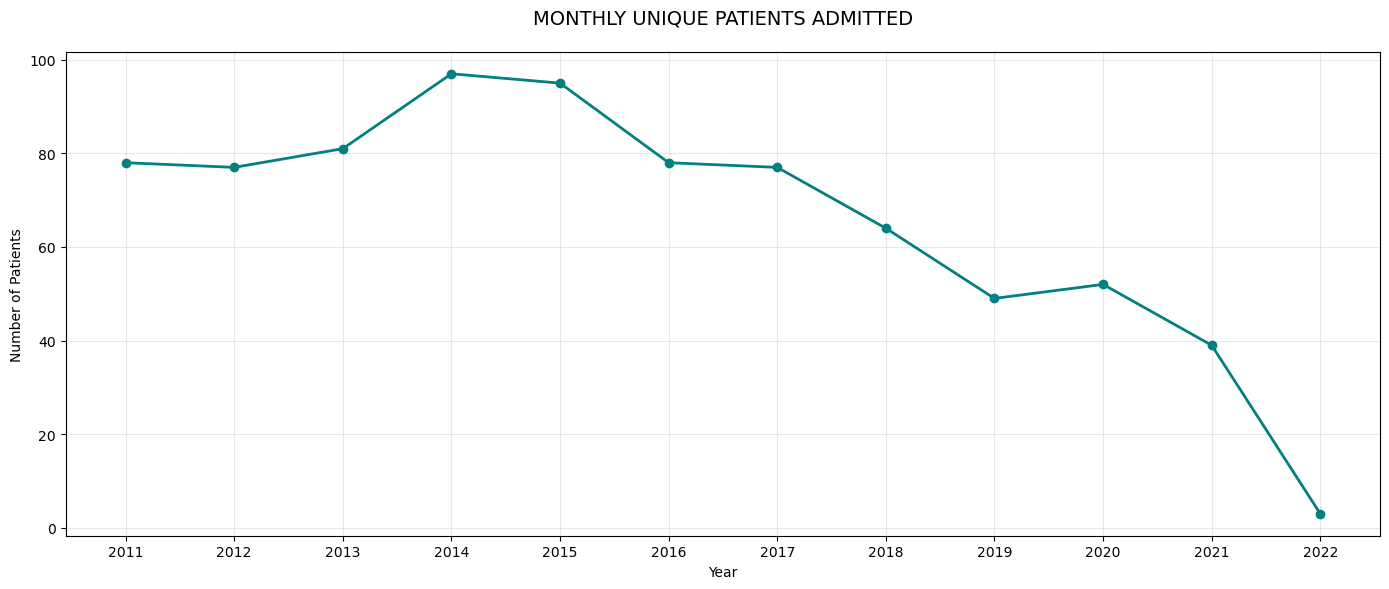

In [24]:
monthly_summary['YEAR']=pd.to_datetime(monthly_summary['MONTH_YEAR']).dt.year
yearly_summary=monthly_summary.groupby('YEAR')['NO_OF_PATIENTS_ADMITTED'].sum()
plt.figure(figsize=(14,6))
plt.plot(yearly_summary.index,
         yearly_summary.values,marker='o', linewidth=2, color='teal')

plt.title('MONTHLY UNIQUE PATIENTS ADMITTED', fontsize=14, pad=20)
plt.xlabel('Year')
plt.ylabel('Number of Patients')
plt.xticks(yearly_summary.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

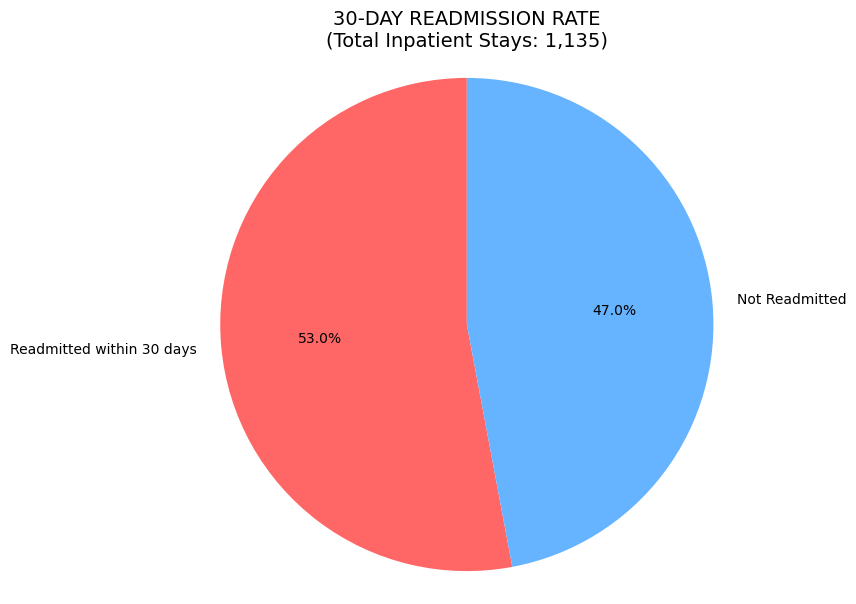

In [25]:
labels = ['Readmitted within 30 days', 'Not Readmitted']
sizes=[601, 1135-601]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff6666','#66b3ff'])
plt.title('30-DAY READMISSION RATE\n(Total Inpatient Stays: 1,135)', fontsize=14)
plt.axis('equal')
plt.show()

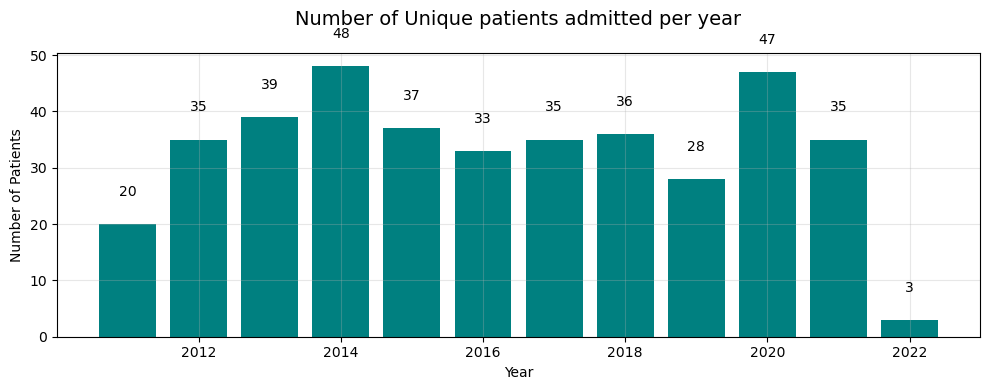

In [26]:
yearly_summary=(monthly_admsn.groupby(monthly_admsn['START'].dt.year)['PATIENT'].nunique().reset_index(name='NO_OF_PATIENTS_ADMITTED'))
plt.figure(figsize=(10,4))
plt.bar(yearly_summary['START'],yearly_summary['NO_OF_PATIENTS_ADMITTED'],color='teal')

plt.title('Number of Unique patients admitted per year', fontsize=14,pad=20)
plt.xlabel('Year')
plt.ylabel('Number of Patients')
plt.grid(True, alpha=0.3)
 ## show numbers untop of bar
for i, v in enumerate(yearly_summary['NO_OF_PATIENTS_ADMITTED']):
    plt.text(yearly_summary['START'].iloc[i], v+5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
monthly_summary_plot=monthly_summary.set_index('MONTH_YEAR').copy()
monthly_summary_plot

,NO_OF_PATIENTS_ADMITTED,PREVIOUS_MONTHS_PATIENTS,GROWTH_RATE_ADMSN_%,YEAR
MONTH_YEAR,,,,
2011-01,7,NaN,0.00,2011
2011-02,8,7.0,14.29,2011
2011-03,6,8.0,-25.00,2011
2011-04,5,6.0,-16.67,2011
2011-05,6,5.0,20.00,2011
...,...,...,...,...
2021-09,4,1.0,300.00,2021
2021-10,5,4.0,25.00,2021
2021-11,3,5.0,-40.00,2021


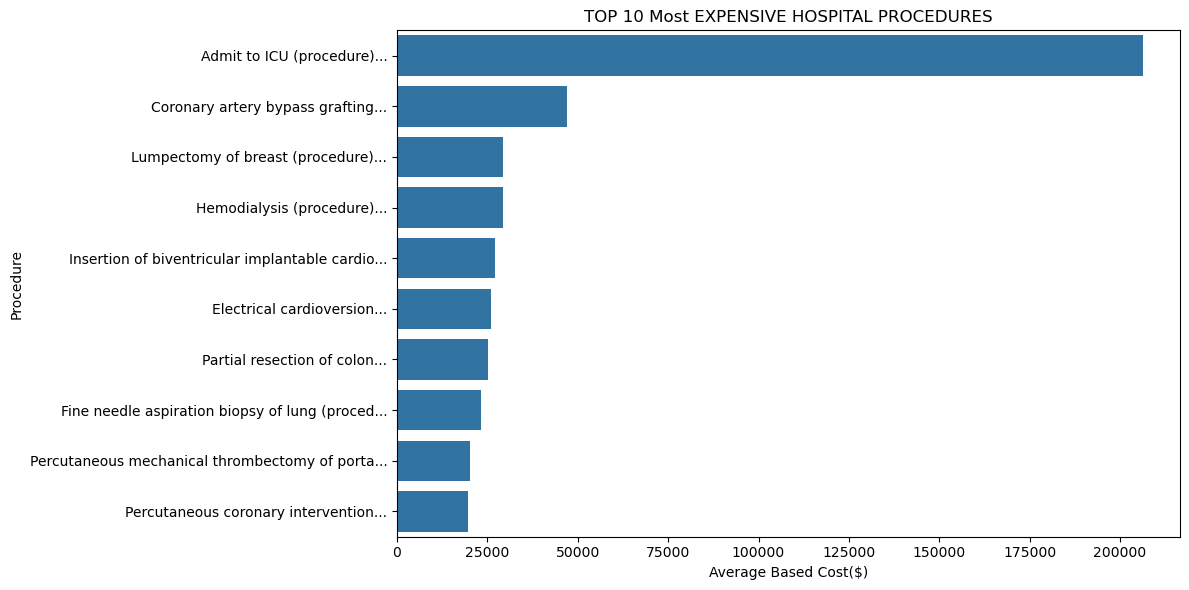

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
top10 = procedure_fqy.head(10).copy()
top10['Clean_names']=top10['DESCRIPTION'].str[:45]+'...'
plt.figure(figsize=(12,6))


sns.barplot(
    data=top10,
    x='AVERAGE_BASED_COST',
    y='Clean_names'
)
plt.title('TOP 10 Most EXPENSIVE HOSPITAL PROCEDURES')
plt.xlabel('Average Based Cost($)')
plt.ylabel('Procedure')
plt.tight_layout()
plt.show()

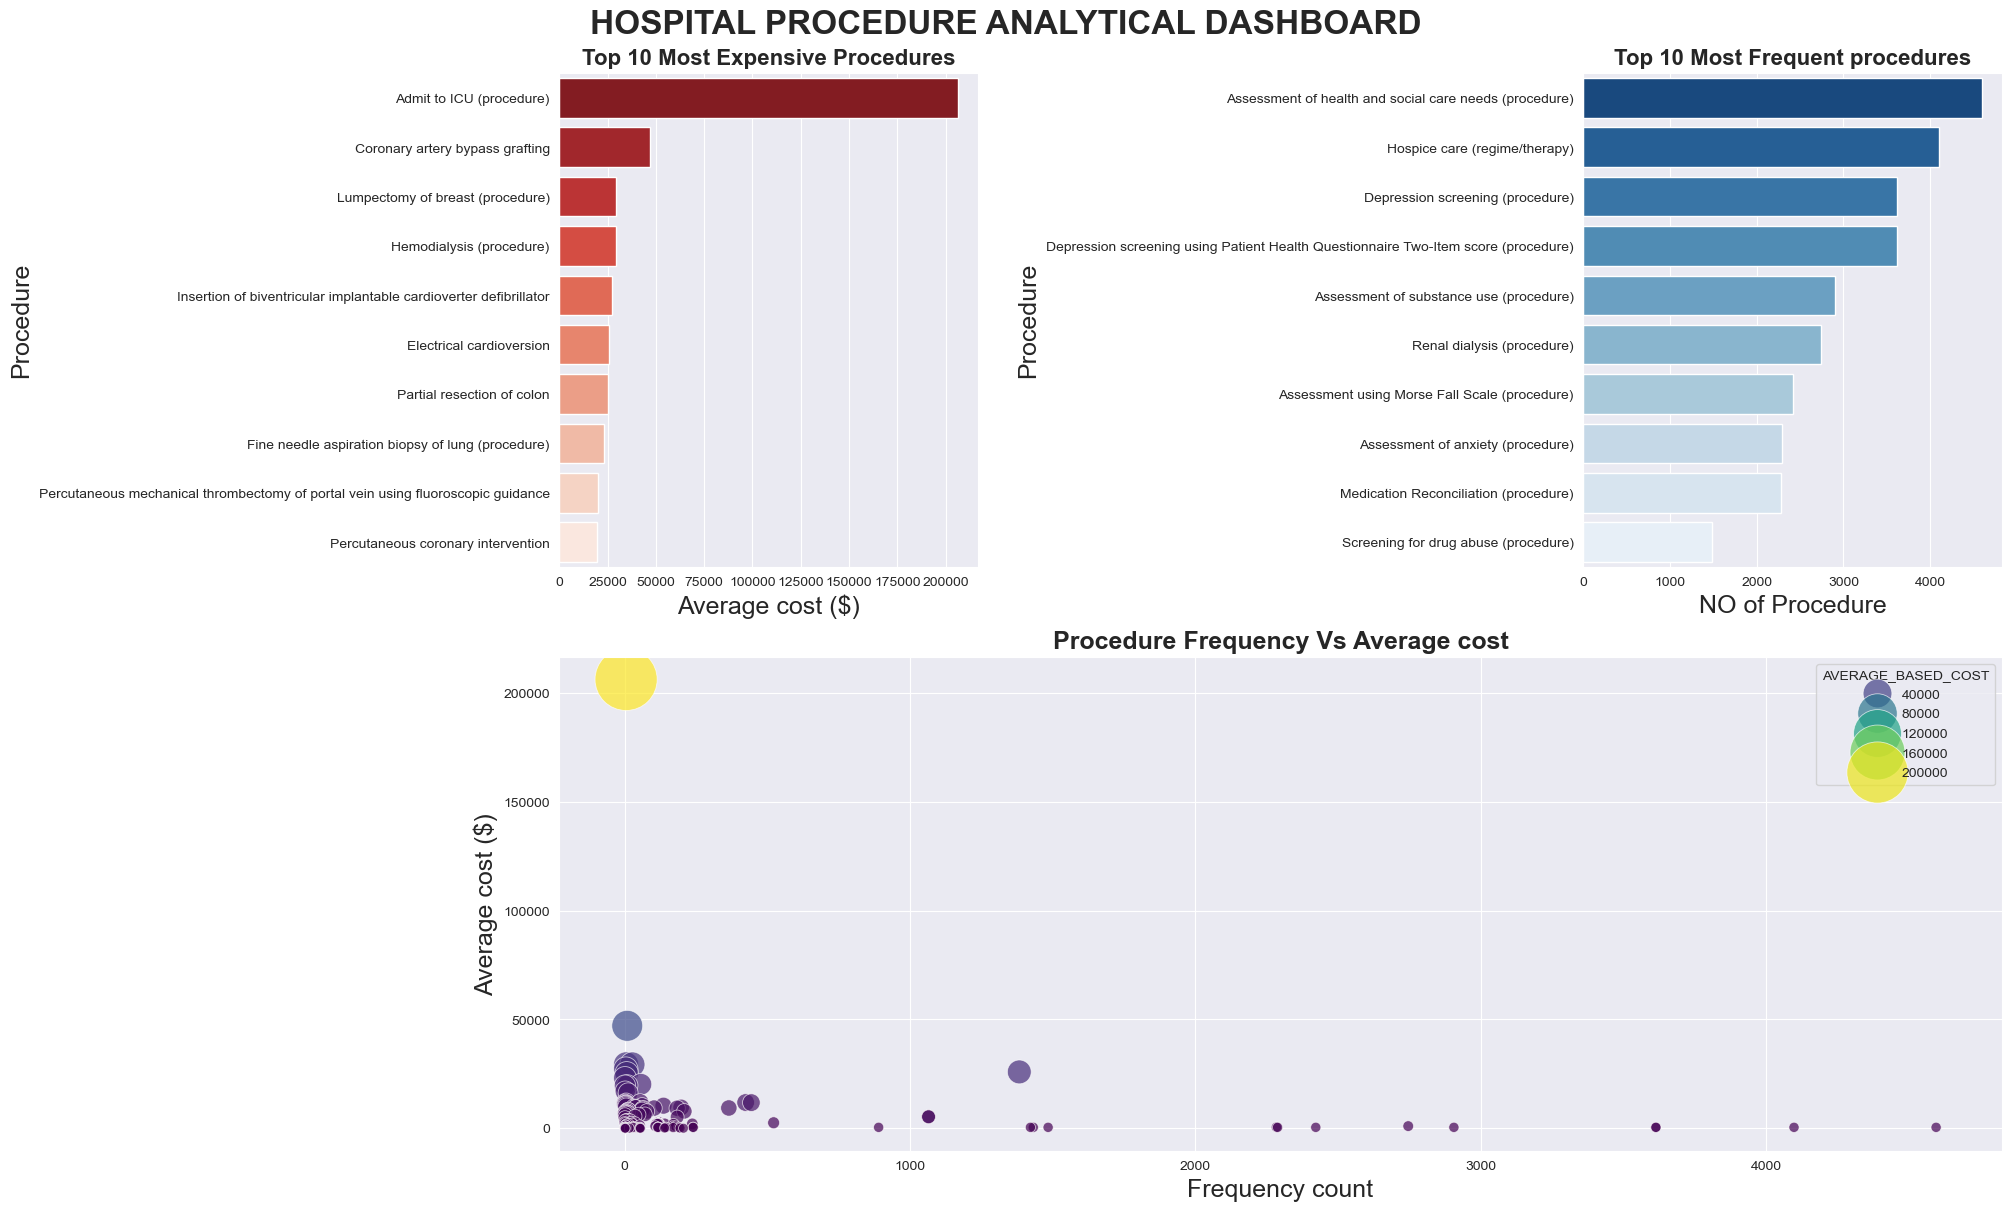

In [29]:
sns.set_style('darkgrid')
top_10_cost= procedure_fqy.sort_values(by='AVERAGE_BASED_COST', ascending=False).head(10)
top_10_count=procedure_fqy_by_count.sort_values(by='COUNT', ascending= False).head(10)

fig=plt.figure(constrained_layout=True,figsize=(20,12))
gs= fig.add_gridspec(2,2)

## Most expensive procedures
ax1= fig.add_subplot(gs[0,0])
sns.barplot(
    data=top_10_cost,
    x='AVERAGE_BASED_COST',
    y='DESCRIPTION',
    hue='DESCRIPTION',
    palette='Reds_r',
    ax=ax1,
    legend=False
)
ax1.set_title(
    'Top 10 Most Expensive Procedures',
    fontsize=16,
    weight='bold'
)
ax1.set_xlabel('Average cost ($)',fontsize=18)
ax1.set_ylabel('Procedure',fontsize=18)

## Most frequent Procedures
ax2= fig.add_subplot(gs[0,1])
sns.barplot(
    data=top_10_count,
    x='COUNT',
    y='DESCRIPTION',
    hue='DESCRIPTION',
    palette='Blues_r',
    ax=ax2,
    legend=False
   )
ax2.set_title(
    'Top 10 Most Frequent procedures',
    fontsize=16,
    weight='bold'
)
ax2.set_xlabel('NO of Procedure',fontsize=18)
ax2.set_ylabel('Procedure',fontsize=18)

## COST VS POCEDURE FREQUENCY
ax3= fig.add_subplot(gs[1, :])
sns.scatterplot(
    data=procedure_fqy,
    x='COUNT',
    y='AVERAGE_BASED_COST',
    size='AVERAGE_BASED_COST',
    hue='AVERAGE_BASED_COST',
    sizes=(50,2000),
    alpha=0.7,
    palette='viridis',
    ax=ax3
)
ax3.set_title(
    'Procedure Frequency Vs Average cost',
    fontsize=18,
    weight='bold'
)
ax3.set_xlabel('Frequency count', fontsize=18)
ax3.set_ylabel('Average cost ($)',fontsize=18)

### DASHBOARD
fig.suptitle(
    'HOSPITAL PROCEDURE ANALYTICAL DASHBOARD',
    fontsize=24,
    weight='bold'
)

plt.show()

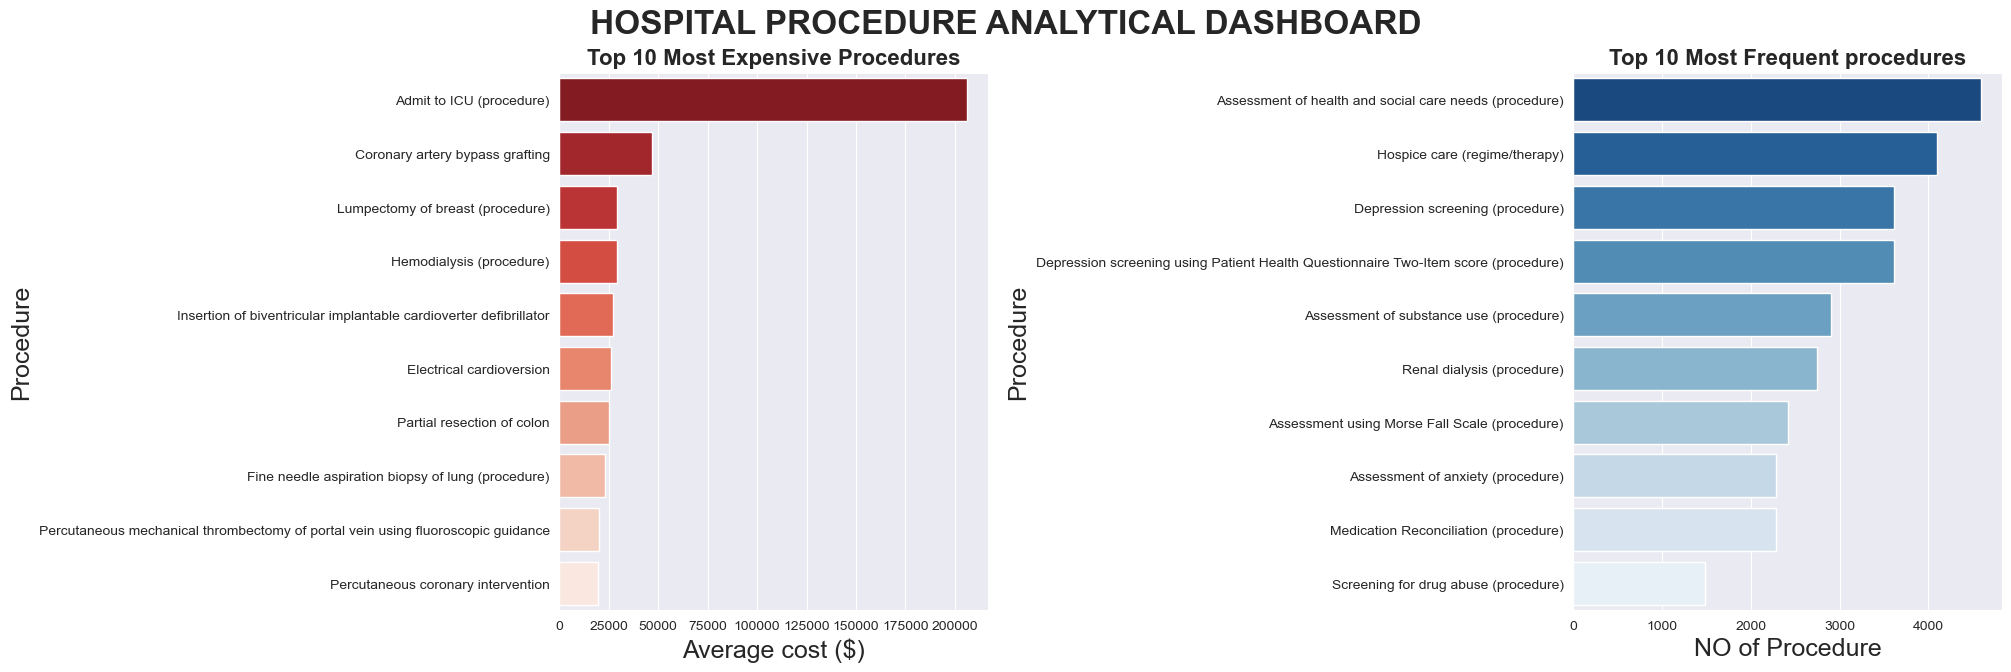

In [30]:
sns.set_style('darkgrid')
top_10_cost= procedure_fqy.sort_values(by='AVERAGE_BASED_COST', ascending=False).head(10)
top_10_count=procedure_fqy_by_count.sort_values(by='COUNT', ascending= False).head(10)

fig=plt.figure(constrained_layout=True,figsize=(20,12))
gs= fig.add_gridspec(2,2)

## Most expensive procedures
ax1= fig.add_subplot(gs[0,0])
sns.barplot(
    data=top_10_cost,
    x='AVERAGE_BASED_COST',
    y='DESCRIPTION',
    hue='DESCRIPTION',
    palette='Reds_r',
    ax=ax1,
    legend=False
)
ax1.set_title(
    'Top 10 Most Expensive Procedures',
    fontsize=16,
    weight='bold'
)
ax1.set_xlabel('Average cost ($)',fontsize=18)
ax1.set_ylabel('Procedure',fontsize=18)

## Most frequent Procedures
ax2= fig.add_subplot(gs[0,1])
sns.barplot(
    data=top_10_count,
    x='COUNT',
    y='DESCRIPTION',
    hue='DESCRIPTION',
    palette='Blues_r',
    ax=ax2,
    legend=False
   )
ax2.set_title(
    'Top 10 Most Frequent procedures',
    fontsize=16,
    weight='bold'
)
ax2.set_xlabel('NO of Procedure',fontsize=18)
ax2.set_ylabel('Procedure',fontsize=18)

fig.suptitle(
    'HOSPITAL PROCEDURE ANALYTICAL DASHBOARD',
    fontsize=24,
    weight='bold'
)

plt.show()

## KEY FINDINGS & INSIGHTS

### 1. Patient Volume & Trends
- Total Inpatient Stays:**1,135**
- Average lenght of stay:**1.5 days**
- Admissions have been Fluctuating, with yearly unique patients ranginf from **20 to 48**.
- Strong growth observed in certain years( as seen 2014 and 200 had the highest volume).

### 2. Readmissions
- **30-day readmission Rate**: **52.95%** (601 readmission events occured)
- Unique patients readmitted within 30 days:**41**
- The rate is notably high and suggest an opportunity for better post-discharge follow-up

### 3. Coverage and Insurance
- Average cost covered by Insurance: **$1,114.97**
 
- Average cost per Encounter: **$3,639.68**
- Insurance/Payer coverage: **51.28%** of encounters had some coverage


### 4. Procedures Findings
- Most expensive procedure on average: **Admit to ICU**(\~$206,260.00)
- Other high-cost procedures include Coronary Artery Bypass Grafting and Lumpectomy.
- High-volume procedures include Electrical cardioversion and Screening for Drug Abuse.

### Business Implications
- High readmission rate indicates potential quality of care or discharge planning issues.
- Significant portion of encounters without insurance coverage may impact hospital revenue.
- ICU admissions drive very high costs - focus on prevention could yield major savings.



In [31]:
datasets={
    'Encounter_per_year': Encounter_per_year,
    'monthly_summary': monthly_summary,
    'top_readmission': top_readmission,
    'unique_per_q' : unique_per_q,
    'merged_df': merged_df,
    'average_claim_cost': average_claim_cost,
    'procedure_fqy' : procedure_fqy,
    'overall_encounter_by_class': overall_encounter_by_class,
    'admissions': admissions,
    
}
for name, data in datasets.items():
    if isinstance(data, pd.Series):
        df_copy=data.to_frame()
    else:
        df_copy= data.copy()
    for col in df_copy.select_dtypes(include=['datetimetz']).columns:
        df_copy[col]=df_copy[col].dt.tz_localize(None)
        
    df_copy.to_csv(f'{name}.csv',index=False)

    df_copy.to_excel(f'{name}.xlsx',index=False)
    print(f'saved {name} as CSV and Execel')

saved Encounter_per_year as CSV and Execel
saved monthly_summary as CSV and Execel
saved top_readmission as CSV and Execel
saved unique_per_q as CSV and Execel
saved merged_df as CSV and Execel
saved average_claim_cost as CSV and Execel
saved procedure_fqy as CSV and Execel
saved overall_encounter_by_class as CSV and Execel
saved admissions as CSV and Execel
